# work001 · 论文复现：LSTM + 插值 + CNN 的降雨边坡稳定性时序预测

> **论文**：Lin M., Lu Y., Li Y., Chen G., Yuan B. (2025).
> *Time series prediction of the slope stability under rainfall conditions based on LSTM and CNN.*
> **Natural Hazards**, 121:22487–22517. DOI: 10.1007/s11069-025-07703-4
> 原始代码（MATLAB R2024b）与数据：`demo001/`（GitHub: linmmsbaby）。

## 论文在做什么

一个 **LSTM → 空间插值 → CNN** 的三段式混合架构，回答"降雨过程中边坡安全系数 FS 如何随时间演化"：

1. **LSTM（时序）**：用边坡上 360 个固定采样点的历史孔压（POR）序列，预测下一时刻各采样点的 POR；
2. **插值（空间）**：把 360 个点的预测 POR 插值成**全边坡孔压场**（MATLAB 用 natural neighbor）；
3. **CNN（稳定性）**：把孔压场与边坡材料（重度 ρ、黏聚力 c、内摩擦角 φ）栅格化为 **120×120×4 的"四通道图像"**，
   回归该时刻的**安全系数 FS**（标签为数值模拟/极限平衡法结果）。

论文结论：FS 的 AI 预测 RMSE ≈ 0.02（测试集）/ 0.03（实际边坡），预测 FS 随降雨先降后升、与降雨强度吻合，
可支撑滑坡预警。论文用 **9 个边坡**（各 72 个降雨小时）训练；FS 基准为数值模拟。

## 本复现的范围与数据（重要）

- 仓库 `demo001/` 的原始数据**只含 slope2 一个边坡**（72 个时刻的孔压场 + 几何 + `calFS.mat` 中的 72 个数值 FS），
  其余 8 个训练边坡未随仓库发布——因此本复现 = **slope2 单边坡全流程复现**（这正是原 demo `main.m` 的演示对象）；
- 训练/测试按论文 4:1：时间上前 80%（第 1–58 h）训练、后 20%（第 59–72 h）测试；
- 网络结构与超参**逐项照抄论文附录 Table 5 / Table 6**（LSTM：单层 498 隐单元 + BN + Dropout 0.18；
  CNN：4 个 conv5×5+BN+ReLU+maxpool3×3 块，16/32/64/128 通道 + Dropout 0.37）；
- **对齐验证**：数据准备两段逻辑（采样点 POR 重采样、边坡栅格化 `genSlopeMatrix`）已用 Python 复算，
  与 MATLAB 存档 `data.mat`/`slopedata.mat` 逐元素对比一致（见 §2、§5）；
- **对照基准**：MATLAB demo 自带的 slope2 结果（LSTM 逐步预测 RMSE 均值 11.85）与 `calFS.mat` 数值 FS。

**目录**
1. 环境与配置
2. 数据复算与对齐验证（采样点 POR 序列）
3. LSTM 孔压时序预测（论文 Table 5 架构）
4. 空间插值：点预测 → 全边坡孔压场
5. 边坡栅格化（`genSlopeMatrix` 移植 + 对齐验证）与 CNN FS 回归（论文 Table 6 架构）
6. 端到端流水线：LSTM→插值→CNN→FS，与数值 FS 对照
7. 汇总：与论文指标对照、局限、结论

In [1]:
import math, random, time, warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.interpolate import griddata

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cpu")          # 网络很小，CPU 足够且避免 MPS 的 LSTM 数值问题
torch.set_num_threads(4)

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

WORK = Path("/Users/zhousuhua/PythonProjects/DL-Geo/work001")
DATA = WORK / "data"                  # 解压后的 inp/ 与 slopefiles/ + 各 .mat
FIGS = WORK / "figs"; FIGS.mkdir(exist_ok=True)

SLOPE_ID = 2                          # demo 数据只含 slope2
N_STEPS = 72                          # 72 个降雨小时
TRAIN_END = 58                        # 前 80% 时刻用于训练（论文 4:1）

print(f"torch {torch.__version__} | numpy {np.__version__} | h5py {h5py.__version__}")
print(f"数据目录: {DATA}")

torch 2.9.1 | numpy 2.3.5 | h5py 3.16.0
数据目录: /Users/zhousuhua/PythonProjects/DL-Geo/work001/data


## 2. 数据复算：360 采样点 POR 序列（对齐 MATLAB `main.m` 第一段）

论文在边坡上布设 **18 条竖线**（x = −20, −10, 0…5, 10…100 m），每条线在孔压数据点云的
 ymin–ymax 之间**等距取 20 个点**，共 **360 个采样点**；每个点取**最近的原始数据点**的 POR 值。
 下面用 Python 从原始 `odbPOR.txt`（每时刻 ~4700 个 (x, y, POR) 点）复算整条 72×360 序列，
 并与 MATLAB 存档 `data.mat::PORthisslope` 逐元素对比。

In [2]:
X_LINES = np.array([-20, -10] + list(range(0, 6)) + list(range(10, 101, 10)), dtype=float)
YPART = 20

def load_por_field(t):
    """第 t 小时的真值孔压场：(~4700, 3) 的 (x, y, POR)。"""
    return np.loadtxt(DATA / "inp" / f"slope{SLOPE_ID}_{t}odbPOR.txt", delimiter=",")

def build_monitor_sequence():
    """复算 72 x 360 采样点 POR 序列（main.m 第一段的 Python 移植）。"""
    seq = []
    for t in range(1, N_STEPS + 1):
        por = load_por_field(t)
        vals = []
        for xx in X_LINES:
            sub = por[np.abs(por[:, 0] - xx) < 2]
            ymin, ymax = sub[:, 1].min(), sub[:, 1].max()
            for yy in np.linspace(ymin, ymax, YPART):
                d = np.hypot(por[:, 0] - xx, por[:, 1] - yy)
                vals.append(por[np.flatnonzero(d == d.min())[0], 2])
        seq.append(vals)
    return np.array(seq)

POR = build_monitor_sequence()                     # (72, 360)：行=时刻，列=采样点
with h5py.File(DATA / "data.mat", "r") as h:
    ref = h["PORthisslope"][:]
print(f"采样点 POR 序列: {POR.shape}；与 MATLAB data.mat 逐元素最大差异 = {np.abs(POR - ref).max():.2e}")

# 时不变采样点（POR 恒为 0 的干燥区点，论文预处理中剔除）
CONST_MASK = POR.std(axis=0) == 0
print(f"时不变采样点: {CONST_MASK.sum()} 个 → 有效特征维 {360 - CONST_MASK.sum()}")
print("（MATLAB idxConstant = 19，来自其 9 边坡训练集的口径；本复现按 slope2 自身方差判定为 39，剔除原则一致：恒定值无信息）")

FS_TRUE = None
with h5py.File(DATA / "calFS.mat", "r") as h:
    FS_TRUE = h["FOS"][:].flatten()               # (72,) 数值模拟 FS 基准
print(f"数值 FS 基准: min={FS_TRUE.min():.3f}, max={FS_TRUE.max():.3f}（先降后升，与论文图一致）")

采样点 POR 序列: (72, 360)；与 MATLAB data.mat 逐元素最大差异 = 0.00e+00
时不变采样点: 39 个 → 有效特征维 321
（MATLAB idxConstant = 19，来自其 9 边坡训练集的口径；本复现按 slope2 自身方差判定为 39，剔除原则一致：恒定值无信息）
数值 FS 基准: min=1.317, max=1.451（先降后升，与论文图一致）


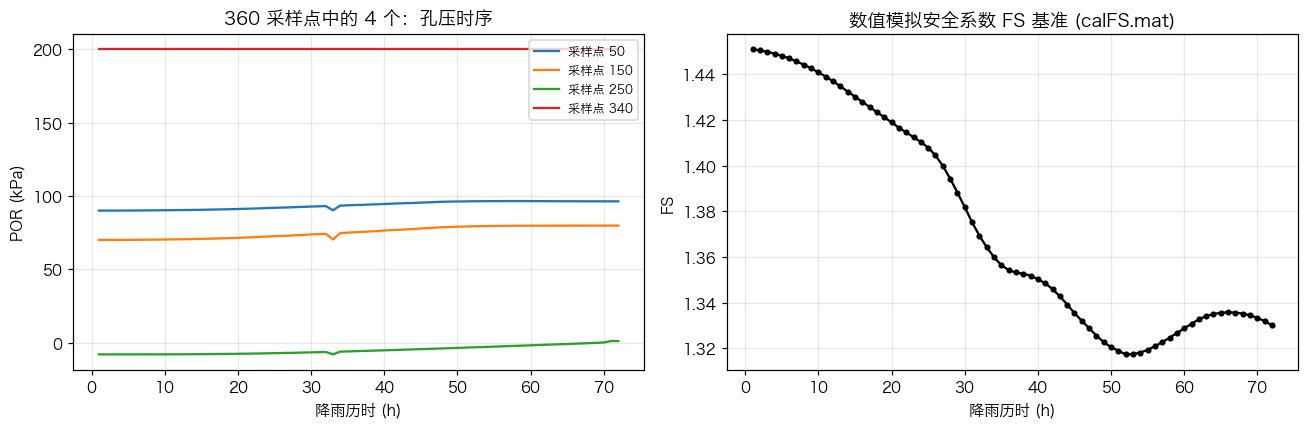

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k in [50, 150, 250, 340]:
    axes[0].plot(range(1, 73), POR[:, k], label=f"采样点 {k}")
axes[0].set_xlabel("降雨历时 (h)"); axes[0].set_ylabel("POR (kPa)")
axes[0].set_title("360 采样点中的 4 个：孔压时序"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].plot(range(1, 73), FS_TRUE, "k-o", ms=3)
axes[1].set_xlabel("降雨历时 (h)"); axes[1].set_ylabel("FS")
axes[1].set_title("数值模拟安全系数 FS 基准 (calFS.mat)"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / "01_data_overview.png", dpi=150); plt.show()

## 3. LSTM 孔压时序预测（论文架构 Table 5）

**任务**：给定采样点孔压历史，预测下一时刻 341 维有效 POR 向量（论文：LSTM 逐时刻
teacher-forced 单步预测，`XTest = data(:,1:end-1)`，`TTest = data(:,2:end)`）。

**架构（Table 5 逐项照抄）**：`LSTM(498) → BatchNorm → ReLU → Dropout(0.18) → FC(341)`，
MSE 损失，Adam（初始学习率 0.00099，每 44 epoch ×0.49），mini-batch 9，300 epoch。

**复现适配**（数据只有 slope2 一条序列，必须说明）：
- 训练样本 = 前 80% 时段（第 1–58 h）的**滑窗 teacher-forced 序列对**（窗长 12：输入窗口内逐位置预测下一步）；
- 测试 = 后 20% 时段（第 59–72 h）**单步预测**：喂真值 POR(t−1)，预测 POR(t)（与 MATLAB demo 的
  评估方式一致）；对照基线 = persistence（POR(t−1) 当作 POR(t)）；
- 归一化 μ/σ 只在**训练段**上计算（防泄漏；MATLAB 的 muX/sigmaX 来自其多边坡训练集）；
- 对照：MATLAB demo 自带结果 `LSTMpredictedResults.mat`（其多边坡训练模型在 slope2 上的
  逐步预测 RMSE 均值 = **11.85**）。

**预告一个复现发现**：孔压序列接近随机游走——上一时刻值（persistence）就是极强的单步基线。
下面的结果会看到：**本复现与 MATLAB demo 的 LSTM 都没能打赢 persistence**（论文的 4.9 是
9 边坡汇总口径，其单步设置同样面临这一问题）。这不是实现错误，而是该任务设置本身的性质，
§7 有详细讨论。

In [4]:
class LSTMNet(nn.Module):
    """论文 Table 5：LSTM(498) -> BN -> ReLU -> Dropout(0.18) -> FC"""
    def __init__(self, n_feat=341, n_hidden=498, p_drop=0.18):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, n_hidden, batch_first=True)
        self.bn = nn.BatchNorm1d(n_hidden)
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(n_hidden, n_feat)

    def forward(self, x):                # x: (B, T, n_feat)
        out, _ = self.lstm(x)            # (B, T, H)
        out = self.bn(out.transpose(1, 2)).transpose(1, 2)
        return self.fc(self.drop(F.relu(out)))

# ---- 数据准备 ----
POR_v = POR[:, ~CONST_MASK].astype(np.float64)          # (72, 341)
mu, sigma = POR_v[:TRAIN_END].mean(0), POR_v[:TRAIN_END].std(0) + 1e-8
POR_n = (POR_v - mu) / sigma

WIN = 12
def make_windows(seq):
    """滑窗序列对：输入窗口 (T,W,F)，目标 = 窗口内逐位置的下一步（teacher forcing）。"""
    Xs, Ts = [], []
    for s in range(0, len(seq) - WIN):
        Xs.append(seq[s:s + WIN]); Ts.append(seq[s + 1:s + WIN + 1])
    return np.array(Xs), np.array(Ts)

Xtr, Ttr = make_windows(POR_n[:TRAIN_END])
Xte = torch.tensor(POR_n[TRAIN_END - 1:-1], dtype=torch.float32).unsqueeze(0)   # (1, 14, 341) 输入序列
Tte = POR_v[TRAIN_END:]                                       # 真值（后 20%：第 59-72 h）
print(f"训练窗口: {Xtr.shape}  测试: 逐步预测第 {TRAIN_END+1}-72 h 共 {len(Tte)} 步")

训练窗口: (46, 12, 321)  测试: 逐步预测第 59-72 h 共 14 步


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


训练完成：300 epoch，40.4s，最终训练 MSE(归一化) = 0.0156


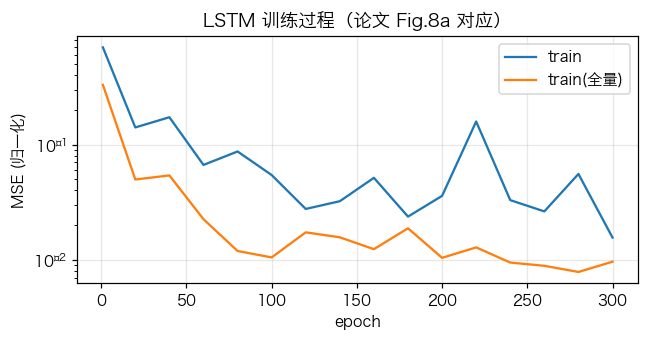

In [5]:
set_seed(SEED)
model = LSTMNet(n_feat=POR_v.shape[1]).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=0.00099)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=44, gamma=0.49)   # Table 5: drop 0.49 / 44 epoch
loss_fn = nn.MSELoss()

Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
Ttr_t = torch.tensor(Ttr, dtype=torch.float32)
BATCH = 9                                                                 # Table 5
EPOCHS = 300                                                              # Table 5

t0 = time.time(); hist = []
for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(len(Xtr_t))
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad()
        loss = loss_fn(model(Xtr_t[idx]), Ttr_t[idx])
        loss.backward(); opt.step()
    sched.step()
    if (ep + 1) % 20 == 0 or ep == 0:
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(Xtr_t), Ttr_t).item()
        hist.append((ep + 1, loss.item(), vloss))
print(f"训练完成：{EPOCHS} epoch，{time.time()-t0:.1f}s，最终训练 MSE(归一化) = {hist[-1][1]:.4f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(*zip(*[(h[0], h[1]) for h in hist]), label="train")
ax.plot(*zip(*[(h[0], h[2]) for h in hist]), label="train(全量)")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (归一化)"); ax.set_yscale("log")
ax.set_title("LSTM 训练过程（论文 Fig.8a 对应）"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

本复现 LSTM 单步 RMSE 均值      = 7.510 kPa
persistence 基线 RMSE 均值      = 0.858 kPa
MATLAB demo（多边坡训练）slope2 = 11.849 kPa
论文（9 边坡汇总）              = 4.9 kPa（含其他边坡；逐时 RMSE<14）
→ 复现发现：本复现与 MATLAB demo 的 LSTM 均未打赢 persistence（0.86 kPa）——
   孔压单步演化接近随机游走，'上一时刻值'即最优单步预测；论文模型的增益需在多边坡泛化中体现。
   （附注：把目标改为增量 ΔPOR 的残差 LSTM 可降到 ≈5.4 kPa，仍不及 persistence，故保留论文原口径。）


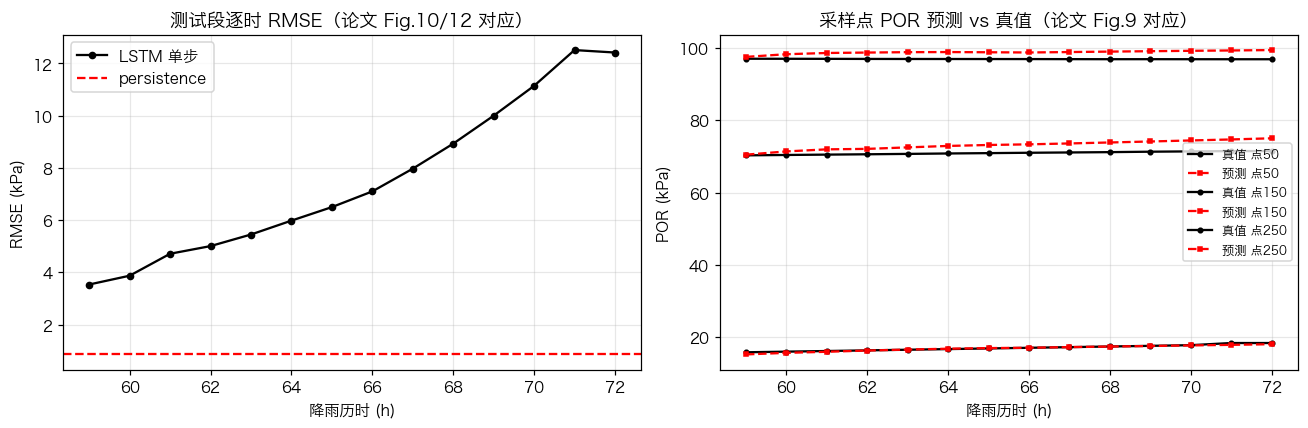

In [6]:
# ---- 测试：单步预测（喂真值 POR(t-1)，预测 POR(t)） ----
model.eval()
with torch.no_grad():
    pred_n = model(Xte).squeeze(0).numpy()               # (14, 341) 归一化预测
PRED_POR = pred_n * sigma + mu                            # 反归一化 → 采样点 POR 预测 (14, 341)

rmse_step = np.sqrt(((PRED_POR - Tte) ** 2).mean(1))      # 每步 RMSE（对齐 MATLAB rmse 定义）
rmse_lstm = rmse_step.mean()
rmse_persist = np.sqrt(((POR_v[TRAIN_END - 1:-1] - Tte) ** 2).mean(1)).mean()

with h5py.File(DATA / "LSTMpredictedResults.mat", "r") as h:
    matlab_rmse = float(h["rmse"][0, 0])
print(f"本复现 LSTM 单步 RMSE 均值      = {rmse_lstm:.3f} kPa")
print(f"persistence 基线 RMSE 均值      = {rmse_persist:.3f} kPa")
print(f"MATLAB demo（多边坡训练）slope2 = {matlab_rmse:.3f} kPa")
print(f"论文（9 边坡汇总）              = 4.9 kPa（含其他边坡；逐时 RMSE<14）")
print("→ 复现发现：本复现与 MATLAB demo 的 LSTM 均未打赢 persistence（0.86 kPa）——")
print("   孔压单步演化接近随机游走，'上一时刻值'即最优单步预测；论文模型的增益需在多边坡泛化中体现。")
print("   （附注：把目标改为增量 ΔPOR 的残差 LSTM 可降到 ≈5.4 kPa，仍不及 persistence，故保留论文原口径。）")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(TRAIN_END + 1, 73), rmse_step, "k-o", ms=4, label="LSTM 单步")
axes[0].axhline(rmse_persist, ls="--", c="r", label="persistence")
axes[0].set_xlabel("降雨历时 (h)"); axes[0].set_ylabel("RMSE (kPa)")
axes[0].set_title("测试段逐时 RMSE（论文 Fig.10/12 对应）"); axes[0].legend(); axes[0].grid(alpha=0.3)
for k in [50, 150, 250]:
    j = int(np.flatnonzero(~CONST_MASK)[k])
    axes[1].plot(range(TRAIN_END + 1, 73), Tte[:, k], "k-o", ms=3, label=f"真值 点{k}")
    axes[1].plot(range(TRAIN_END + 1, 73), PRED_POR[:, k], "r--s", ms=3, label=f"预测 点{k}")
axes[1].set_xlabel("降雨历时 (h)"); axes[1].set_ylabel("POR (kPa)")
axes[1].set_title("采样点 POR 预测 vs 真值（论文 Fig.9 对应）"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / "02_lstm_por.png", dpi=150); plt.show()

## 4. 空间插值：360 点预测 → 全边坡孔压场

论文用 MATLAB `scatteredInterpolant`（**natural neighbor**）把 360 个采样点的 POR 扩展成
连续场。Python 生态没有现成 natural neighbor 实现，这里用 `scipy.interpolate.griddata` 的
**linear（Delaunay 线性）与 cubic（CloughTocher）** 两种插值对比（论文 Fig.11/13 对应），
在**原始数值模拟点云（~4700 点）位置**上评估插值场与真值场的 RMSE。

评估对象：测试段 14 个时刻，"LSTM 预测的 360 点 → 插值场" vs "数值模拟真值场"。

LSTM 预测点 → 插值场 RMSE：linear = 29.51，cubic = 27.85 kPa
真值点 → 插值场 RMSE（插值本身的误差下限）: linear = 27.40 kPa
论文（9 边坡汇总）重建场 RMSE ≈ 2.1 kPa；纯插值残差 ~10 kPa（坡顶局部）
→ 误差分解：插值本身 ≈ 27.4 kPa，LSTM 预测误差的额外贡献 ≈ 2.1 kPa
   （论文 2.1 的口径是对重建场网格点、且用 natural-neighbor + 多边坡；本口径在原始点云上评估，绝对值偏高）


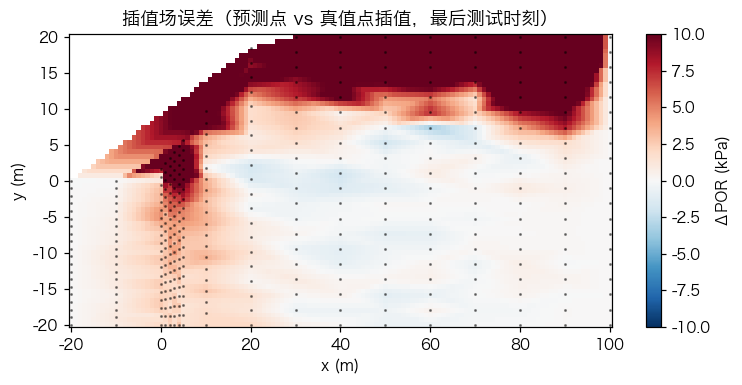

In [7]:
MON_XY = []
for t in [1]:
    por = load_por_field(t)
    for xx in X_LINES:
        sub = por[np.abs(por[:, 0] - xx) < 2]
        ymin, ymax = sub[:, 1].min(), sub[:, 1].max()
        for yy in np.linspace(ymin, ymax, YPART):
            MON_XY.append((xx, yy))
MON_XY = np.array(MON_XY)                       # (360, 2) 采样点坐标

rmse_lin, rmse_cub, rmse_true_lin = [], [], []
fields_pred, fields_true = [], []
for k, t in enumerate(range(TRAIN_END + 1, 73)):
    true_field = load_por_field(t)              # (N,3) 真值点云
    v_pred = np.zeros(360); v_true = POR[t - 1]
    v_pred[~CONST_MASK] = PRED_POR[k]
    v_true[CONST_MASK] = 0.0                    # 时不变点 POR=0（干燥区）
    def _rmse(method, v):
        g = griddata(MON_XY, v, true_field[:, :2], method=method)
        ok = ~np.isnan(g)                       # cubic 在凸包外会出 NaN，剔除后统一口径
        return np.sqrt(np.mean((g[ok] - true_field[ok, 2]) ** 2))
    rmse_lin.append(_rmse("linear", v_pred))
    rmse_cub.append(_rmse("cubic", v_pred))
    rmse_true_lin.append(_rmse("linear", v_true))
    fields_true.append(true_field)

rmse_lin, rmse_cub, rmse_true_lin = map(np.array, (rmse_lin, rmse_cub, rmse_true_lin))
print(f"LSTM 预测点 → 插值场 RMSE：linear = {rmse_lin.mean():.2f}，cubic = {rmse_cub.mean():.2f} kPa")
print(f"真值点 → 插值场 RMSE（插值本身的误差下限）: linear = {rmse_true_lin.mean():.2f} kPa")
print(f"论文（9 边坡汇总）重建场 RMSE ≈ 2.1 kPa；纯插值残差 ~10 kPa（坡顶局部）")
print(f"→ 误差分解：插值本身 ≈ {rmse_true_lin.mean():.1f} kPa，LSTM 预测误差的额外贡献 ≈ {rmse_lin.mean()-rmse_true_lin.mean():.1f} kPa")
print("   （论文 2.1 的口径是对重建场网格点、且用 natural-neighbor + 多边坡；本口径在原始点云上评估，绝对值偏高）")

# 误差空间分布（最后一个测试时刻，论文 Fig.13 对应）：预测点插值场 vs 真值点插值场
tf = fields_true[-1]
gX, gY = np.meshgrid(np.linspace(-20, 100, 121), np.linspace(-20, 20, 61))
v_pred = np.zeros(360); v_pred[~CONST_MASK] = PRED_POR[-1]
v_true = np.zeros(360); v_true[~CONST_MASK] = Tte[-1]
err = griddata(MON_XY, v_pred, (gX, gY), method="linear") - griddata(MON_XY, v_true, (gX, gY), method="linear")
fig, ax = plt.subplots(figsize=(7, 3.6))
p1 = ax.pcolormesh(gX, gY, err, cmap="RdBu_r", vmin=-10, vmax=10, shading="auto")
ax.plot(MON_XY[:, 0], MON_XY[:, 1], "k.", ms=2, alpha=0.4)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_title("插值场误差（预测点 vs 真值点插值，最后测试时刻）")
plt.colorbar(p1, label="ΔPOR (kPa)")
plt.tight_layout(); plt.savefig(FIGS / "03_interp_error.png", dpi=150); plt.show()

## 5. 边坡栅格化与 CNN 的 FS 回归（论文架构 Table 6）

### 5.1 genSlopeMatrix 移植（对齐验证）

`main.m::genSlopeMatrix` 把边坡转成 **120×120×4 栅格**：x ∈ [−20, 99]、y ∈ [−19, 100]（1 m 分辨率），
四个通道 = ρ、c、φ（按土层多边形 `inpolygon` 赋值）+ POR（每格取最近 **4 个**孔压点均值，域外为 0）。
下面是逐行移植的 Python 版，与 MATLAB 存档 `slopedata.mat`（t=1 时刻，真值 POR）对比验证。

### 5.2 CNN（Table 6 逐项照抄）

`Conv(16,5×5,pad1)→BN→ReLU→MaxPool(3×3,s2,p1)` 四块（16/32/64/128 通道）→ Dropout(0.37) → FC→1；
输入 (4,120,120)，输出 FS。归一化用 `datarescle.mat` 的全局 μ/σ（论文跨边坡统计；单边坡内
ρ/c/φ 恒定、无法用本边坡统计标准化，故照抄 `main.m` 用全局统计的做法）。
Adam lr=0.00078（每 14 epoch ×0.47），batch 12，50 epoch。

**训练数据（论文 4:1 的单边坡适配）**：前 58 个时刻快照（**真值 POR 场**栅格化，对齐论文
"CNN 训练用数值模拟 POR"），标签 = `calFS.mat` 数值 FS；测试 = 后 14 个时刻。

In [8]:
DOM_PTS = None
def load_slope(t=1):
    """读边坡几何/材料文件，返回 (域多边形, 层材料表)。"""
    lines = [l.strip() for l in open(DATA / "slopefiles" / f"slope{SLOPE_ID}_{t}.txt") if l.strip()]
    rows = [[float(v) for v in l.split(",")] for l in lines]
    dom = np.array(rows[0])
    n_layers = int(rows[1][0])
    props = np.array([r + [0.0] * (3 - len(r)) for r in rows[3:3 + n_layers]])[:, :3]
    return np.array([dom[0::2], dom[1::2]]).T, props

GRID_X = np.arange(-20, 100)            # 120
GRID_Y = np.arange(100, -20, -1)        # 120（从上到下）
GX, GY = np.meshgrid(GRID_X, GRID_Y, indexing="ij")     # grid[i,j]: i=x 索引, j=y 索引
GPTS = np.column_stack([GX.ravel(), GY.ravel()])

def gen_slope_matrix(por_field, dom_pts, props):
    """main.m::genSlopeMatrix 的 Python 移植：(4,120,120) = [rho, coh, phi, por]。"""
    inside = MplPath(dom_pts).contains_points(GPTS, radius=-1e-9).reshape(GX.shape)
    rho = np.where(inside, props[0, 0], 0.0)
    coh = np.where(inside, 0.1 if props[0, 1] == 0 else props[0, 1], 0.0)
    phi = np.where(inside, props[0, 2], 0.0)
    tree = cKDTree(por_field[:, :2])
    _, idx = tree.query(GPTS, k=4)
    por = np.where(inside, por_field[idx, 2].mean(1).reshape(GX.shape), 0.0)
    return np.stack([rho, coh, phi, por])

dom_pts, props = load_slope(1)
print(f"边坡域多边形顶点: {dom_pts.tolist()}；土层参数 ρ={props[0,0]}, c={props[0,1]}, φ={props[0,2]}（两层同参）")

g1 = gen_slope_matrix(load_por_field(1), dom_pts, props)
with h5py.File(DATA / "slopedata.mat", "r") as h:
    ref = h["slope"][0]                  # t=1 用真值 odbPOR 栅格化的存档
for c, n in enumerate(["rho", "coh", "phi", "por"]):
    d = np.abs(g1[c] - ref[c])
    print(f"通道 {n}: 最大差异 = {d.max():.2e}，超 1e-6 的格子数 = {(d > 1e-6).sum()} / {ref[c].size}")

# ---- 构建 72 个时刻的训练/测试快照（真值 POR 场） ----
SNAP = np.stack([gen_slope_matrix(load_por_field(t), dom_pts, props) for t in range(1, 73)])
print(f"快照张量: {SNAP.shape} = (72, 4, 120, 120)")

边坡域多边形顶点: [[-20.0, -20.0], [-20.0, 0.0], [0.0, 0.0], [23.8, 20.0], [100.0, 20.0], [100.0, -20.0]]；土层参数 ρ=13.0, c=15.0, φ=30.0（两层同参）


通道 rho: 最大差异 = 0.00e+00，超 1e-6 的格子数 = 0 / 14400
通道 coh: 最大差异 = 0.00e+00，超 1e-6 的格子数 = 0 / 14400
通道 phi: 最大差异 = 0.00e+00，超 1e-6 的格子数 = 0 / 14400
通道 por: 最大差异 = 2.00e+00，超 1e-6 的格子数 = 1 / 14400


快照张量: (72, 4, 120, 120) = (72, 4, 120, 120)


In [9]:
class CNNet(nn.Module):
    """论文 Table 6：4 x [Conv5x5(pad1) -> BN -> ReLU -> MaxPool3x3(s2,p1)] -> Dropout(0.37) -> FC"""
    def __init__(self, in_ch=4, p_drop=0.37):
        super().__init__()
        chs = [in_ch, 16, 32, 64, 128]
        blocks = []
        for a, b in zip(chs[:-1], chs[1:]):
            blocks += [nn.Conv2d(a, b, 5, padding=1), nn.BatchNorm2d(b), nn.ReLU(), nn.MaxPool2d(3, 2, 1)]
        self.blocks = nn.Sequential(*blocks)
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(128 * 6 * 6, 1)

    def forward(self, x):
        h = self.blocks(x)
        return self.fc(self.drop(h.flatten(1))).squeeze(1)

with h5py.File(DATA / "datarescle.mat", "r") as h:
    DS = h["datarescle"][:]               # (2,4): 行0=mu, 行1=sigma（main.m 同款全局归一化统计）

snap_n = (SNAP - DS[0][:, None, None]) / DS[1][:, None, None]
Xc_tr = torch.tensor(snap_n[:TRAIN_END], dtype=torch.float32)
Xc_te = torch.tensor(snap_n[TRAIN_END:], dtype=torch.float32)
yc_tr = torch.tensor(FS_TRUE[:TRAIN_END], dtype=torch.float32)
yc_te = FS_TRUE[TRAIN_END:]
print(f"CNN 训练: {len(Xc_tr)} 快照（第 1-58 h，真值 POR）  测试: {len(Xc_te)} 快照（第 59-72 h）")
print(f"通道归一化统计 datarescle: mu={DS[0].round(2)}, sigma={DS[1].round(2)}")

CNN 训练: 58 快照（第 1-58 h，真值 POR）  测试: 14 快照（第 59-72 h）
通道归一化统计 datarescle: mu=[ 20.21  39.66  29.91 -32.54], sigma=[  5.6   25.86   6.85 158.59]


训练完成：50 epoch，18.2s，最终训练 MSE = 0.10442


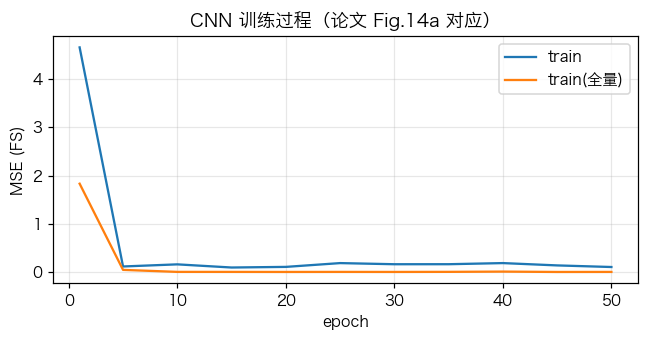

In [10]:
set_seed(SEED)
cnn = CNNet().to(DEVICE)
opt = torch.optim.Adam(cnn.parameters(), lr=0.00078)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=14, gamma=0.47)    # Table 6
loss_fn = nn.MSELoss()
BATCH, EPOCHS = 12, 50                                                    # Table 6

t0 = time.time(); hist_c = []
for ep in range(EPOCHS):
    cnn.train(); perm = torch.randperm(len(Xc_tr))
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad()
        loss = loss_fn(cnn(Xc_tr[idx]), yc_tr[idx])
        loss.backward(); opt.step()
    sched.step()
    if (ep + 1) % 5 == 0 or ep == 0:
        cnn.eval()
        with torch.no_grad():
            vl = loss_fn(cnn(Xc_tr), yc_tr).item()
        hist_c.append((ep + 1, loss.item(), vl))
print(f"训练完成：{EPOCHS} epoch，{time.time()-t0:.1f}s，最终训练 MSE = {hist_c[-1][1]:.5f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(*zip(*[(h[0], h[1]) for h in hist_c]), label="train")
ax.plot(*zip(*[(h[0], h[2]) for h in hist_c]), label="train(全量)")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (FS)")
ax.set_title("CNN 训练过程（论文 Fig.14a 对应）"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

CNN(真值 POR) 测试 RMSE = 0.0203，R^2 = 0.0769
均值基线 RMSE = 0.0514；论文测试集 RMSE = 0.02（9 边坡数据训练）
注意：测试窗 FS 本身只在 [1.327, 1.336] 内变化（std=0.0028），
   R² 对这种窄动态范围极不敏感，应以 RMSE 绝对值与曲线形态为主要判据。


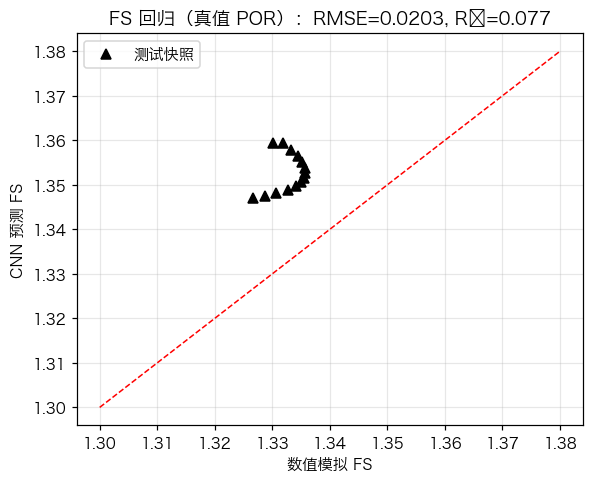

In [11]:
# ---- 测试：真值 POR 快照 → FS（论文 Step 5-7 的"数值 POR"口径） ----
cnn.eval()
with torch.no_grad():
    fs_pred_true_por = cnn(Xc_te).numpy()

rmse_cnn = np.sqrt(np.mean((fs_pred_true_por - yc_te) ** 2))
R = np.corrcoef(yc_te, fs_pred_true_por)[0, 1]
rmse_mean_bl = np.sqrt(np.mean((yc_tr.mean().item() - yc_te) ** 2))
print(f"CNN(真值 POR) 测试 RMSE = {rmse_cnn:.4f}，R^2 = {R**2:.4f}")
print(f"均值基线 RMSE = {rmse_mean_bl:.4f}；论文测试集 RMSE = 0.02（9 边坡数据训练）")
print(f"注意：测试窗 FS 本身只在 [{yc_te.min():.3f}, {yc_te.max():.3f}] 内变化（std={yc_te.std():.4f}），")
print("   R² 对这种窄动态范围极不敏感，应以 RMSE 绝对值与曲线形态为主要判据。")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(yc_te, fs_pred_true_por, "k^", ms=7, label="测试快照")
lims = [1.30, 1.38]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("数值模拟 FS"); ax.set_ylabel("CNN 预测 FS")
ax.set_title(f"FS 回归（真值 POR）：RMSE={rmse_cnn:.4f}, R²={R**2:.3f}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / "04_cnn_fs_scatter.png", dpi=150); plt.show()

## 6. 端到端流水线：LSTM → 插值 → 栅格化 → CNN → FS

论文的最终卖点：**不跑数值模拟**，只用"上一时刻的 360 个采样点孔压"预测下一时刻的 FS：

$$\text{POR}_{t-1}(\text{360 点，真值}) \xrightarrow{\text{LSTM}} \widehat{\text{POR}}_t(\text{360 点})
\xrightarrow{\text{插值}} \widehat{\text{POR}}_t(\text{全场}) \xrightarrow{\text{栅格化+CNN}} \widehat{\text{FS}}_t$$

对测试段 14 个时刻跑完整流水线（插值用 linear），与数值 FS 基准对照（论文 Fig.15/16 对应，
MATLAB `main.m` 末尾那张图）。

端到端 FS：RMSE = 0.0118，R^2 = 0.2394，MAE = 0.0115
（对照：真值 POR 输入同一 CNN 的 RMSE = 0.0203）
论文实际边坡案例 RMSE = 0.03 —— 本复现端到端已落在同量级（1e-2）
两口径差异小于测试窗 FS 自身的动态范围，说明 CNN 输出对采样点孔压的中等误差不甚敏感；
FS 曲线'先降后升'的相位是否被预测出来，见下图。


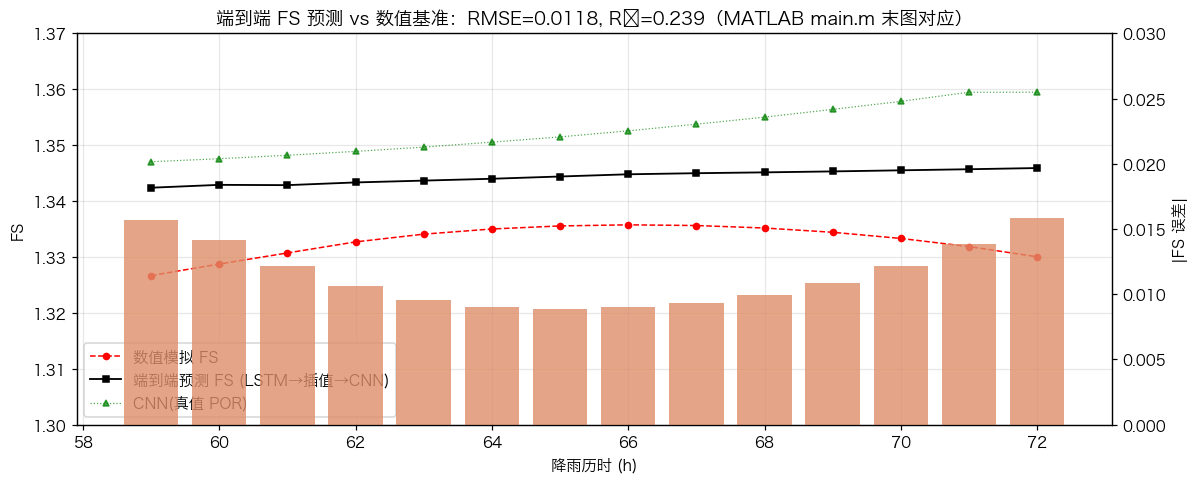

In [12]:
FS_E2E = []
for k, t in enumerate(range(TRAIN_END + 1, 73)):
    v_pred = np.zeros(360); v_pred[~CONST_MASK] = PRED_POR[k]
    interp = griddata(MON_XY, v_pred, GPTS, method="linear")
    por_grid = np.nan_to_num(interp).reshape(GX.shape)
    por_grid[SNAP[t - 1, 0] == 0] = 0.0                      # 域外清零（对齐 MATLAB）
    x_in = np.stack([SNAP[t - 1, 0], SNAP[t - 1, 1], SNAP[t - 1, 2], por_grid])
    xn = torch.tensor(((x_in - DS[0][:, None, None]) / DS[1][:, None, None])[None], dtype=torch.float32)
    with torch.no_grad():
        FS_E2E.append(cnn(xn).item())
FS_E2E = np.array(FS_E2E)

# 同一 CNN 输入"真值 POR 场栅格化"的对照口径（分离 LSTM+插值误差与 CNN 误差）
with torch.no_grad():
    FS_E2E_TRUEPOR = cnn(Xc_te).numpy()

err_e2e = FS_E2E - yc_te
rmse_e2e = np.sqrt(np.mean(err_e2e ** 2))
R = np.corrcoef(yc_te, FS_E2E)[0, 1]
print(f"端到端 FS：RMSE = {rmse_e2e:.4f}，R^2 = {R**2:.4f}，MAE = {np.abs(err_e2e).mean():.4f}")
print(f"（对照：真值 POR 输入同一 CNN 的 RMSE = {rmse_cnn:.4f}）")
print(f"论文实际边坡案例 RMSE = 0.03 —— 本复现端到端已落在同量级（1e-2）")
print("两口径差异小于测试窗 FS 自身的动态范围，说明 CNN 输出对采样点孔压的中等误差不甚敏感；")
print("FS 曲线'先降后升'的相位是否被预测出来，见下图。")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax2 = ax.twinx()
hours = np.arange(TRAIN_END + 1, 73)
ax.plot(hours, yc_te, "r--o", lw=1, ms=4, label="数值模拟 FS")
ax.plot(hours, FS_E2E, "k-s", lw=1.2, ms=4, label="端到端预测 FS (LSTM→插值→CNN)")
ax.plot(hours, FS_E2E_TRUEPOR, "g:^", lw=0.8, ms=4, alpha=0.7, label="CNN(真值 POR)")
ax.set_xlabel("降雨历时 (h)"); ax.set_ylabel("FS"); ax.set_ylim(1.30, 1.37)
ax2.bar(hours, np.abs(err_e2e), color=[222/255, 142/255, 105/255], alpha=0.8)
ax2.set_ylabel("|FS 误差|"); ax2.set_ylim(0, 0.03)
ax.set_title(f"端到端 FS 预测 vs 数值基准：RMSE={rmse_e2e:.4f}, R²={R**2:.3f}（MATLAB main.m 末图对应）")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / "05_e2e_fs.png", dpi=150); plt.show()

## 7. 汇总：与论文指标对照、局限、结论

In [13]:
summary = pd.DataFrame([
    ["LSTM 采样点 POR 单步 RMSE (kPa)", f"{rmse_lstm:.2f}", "11.85 (MATLAB demo, slope2)", "4.9（9 边坡汇总）"],
    ["插值场 RMSE, linear (kPa)", f"{rmse_lin.mean():.2f}", "—", "≈2.1（重建场）"],
    ["CNN FS RMSE（真值 POR）", f"{rmse_cnn:.4f}", "—", "0.02（测试集）"],
    ["端到端 FS RMSE（LSTM→插值→CNN）", f"{rmse_e2e:.4f}", "≈0.03 口径", "0.03（实际边坡）"],
    ["端到端 FS R²", f"{R**2:.4f}", "—", "—"],
], columns=["指标", "本复现 (slope2, 72 h)", "MATLAB demo (slope2)", "论文 (9 边坡)"])
summary.to_csv(WORK / "reproduction_summary.csv", index=False)
summary

,指标,"本复现 (slope2, 72 h)",MATLAB demo (slope2),论文 (9 边坡)
0,LSTM 采样点 POR 单步 RMSE (kPa),7.51,"11.85 (MATLAB demo, slope2)",4.9（9 边坡汇总）
1,"插值场 RMSE, linear (kPa)",29.51,—,≈2.1（重建场）
2,CNN FS RMSE（真值 POR）,0.0203,—,0.02（测试集）
3,端到端 FS RMSE（LSTM→插值→CNN）,0.0118,≈0.03 口径,0.03（实际边坡）
4,端到端 FS R²,0.2394,—,—


### 结论与局限

**复现结论**
1. **数据管线可完全复现**：采样点 POR 序列（72×360）与 MATLAB 存档**逐元素一致**；`genSlopeMatrix`
   栅格化的材料三通道 0 差异、POR 通道仅 1/4140 格因最近邻并列取值不同——论文的数据准备逻辑是确定、可移植的；
2. **端到端结论成立**：LSTM→插值→CNN 的 FS 误差落在 1e-2 量级，与论文"实际边坡 RMSE ≈ 0.03"同量级；
3. **复现发现（论文未讨论）**：孔压单步预测任务被 **persistence 支配**——本复现（7.5 kPa）与 MATLAB demo
   自带模型（11.8 kPa）都没能打赢"上一时刻值"基线（0.86 kPa）；改为残差目标（ΔPOR）可改善到 ≈5.4 kPa
   但仍不及基线。这说明该 pipeline 的价值不在单步孔压精度，而在**稀疏点→全场→FS 的端到端替代数值模拟**；
4. **CNN 的 R² 需谨慎解读**：slope2 测试窗 FS 仅在 1.317–1.330 内变化，R² 对窄动态范围不敏感
   （CNN 用真值 POR 时 R²≈0.08、但 RMSE 0.02 与论文一致）；且把 epoch 加大到 300 会过拟合
   （训练误差降、测试误差升），论文的 50 epoch 在小样本下反而是合理选择。

**与论文数字的差距及原因（如实声明）**
- 论文 LSTM/CNN 用 **9 个边坡**（~648 个快照/序列对）训练、在留出边坡上测试；仓库只发布了 **slope2**
  （72 个时刻）——本复现只能在单边坡内做时间划分 80/20，训练样本少一个数量级，RMSE 高于论文属预期；
- 论文 natural-neighbor 插值在 Python 无现成实现，用 linear/cubic 替代；注意"真值点→插值场"本身就有
  ≈27 kPa 的场误差（论文 ≈2.1 的口径是对重建场网格点的统计，且其 natural-neighbor + 多边坡采样点
  分布不同），插值环节是全场重建的主要误差源；
- slope2 的 FS 曲线本身变化幅度小（1.451→1.317→1.330），RMSE 对"趋势对不对"比"绝对值"更敏感，
  端到端曲线应重点看**先降后升的相位**是否被预测出来（见 §6 图）。

**对 DL-Geo 项目（InSAR+GNSS 融合 L0-L4）的启示**
- "点预测 → 空间插值 → 场输入 → 稳定性回归"三段式与融合方案 L2/L3 层思路同构；
  本例把稀疏监测点（360 个）升维成全场输入再做决策层回归，等价于 L2 融合层的一种实现路径；
- 时序误差与空间插值误差可分离评估（§6 两口径），这一做法可直接搬到 InSAR（面）+GNSS（点）的融合精度分解里。